# Face Recognition Dataset – Exploratory Data Analysis (EDA) v2

This notebook performs EDA on the dataset in **three complementary ways**:

1. **Pairs-based view (Train/Test)**: loads images exactly as verification training does, from `pairsDevTrain.txt` and `pairsDevTest.txt`.
2. **Full-images view (All identities)**: scans the entire `images/` folder (all identities and all images available).
3. **Image statistics (Grayscale)**: computes per-image and global statistics assuming **grayscale images** (single channel), and visualizes **distributions** (not just numbers).

> If your images are actually RGB, you can flip a single switch in the stats section; by default we treat them as grayscale.


## Setup

Update these paths only if your project layout differs.

Expected layout:
- `assets/pairsDevTrain.txt`
- `assets/pairsDevTest.txt`
- `images/<identity>/<identity>_0001.jpg`


In [14]:
from pathlib import Path
from collections import Counter
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import random

def find_project_root(markers=("assets", "images", "src")):
    p = Path.cwd().resolve()
    for parent in [p] + list(p.parents):
        if all((parent / m).exists() for m in markers):
            return parent
    raise RuntimeError(f"Project root not found from cwd={p}. Expected markers={markers}")

PROJECT_ROOT = find_project_root()
IMAGES_ROOT  = PROJECT_ROOT / "images"
ASSETS_ROOT  = PROJECT_ROOT / "assets"

TRAIN_PAIRS = ASSETS_ROOT / "pairsDevTrain.txt"
TEST_PAIRS  = ASSETS_ROOT / "pairsDevTest.txt"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("IMAGES_ROOT :", IMAGES_ROOT)
print("ASSETS_ROOT :", ASSETS_ROOT)

assert IMAGES_ROOT.exists(), "images/ not found"
assert ASSETS_ROOT.exists(), "assets/ not found"
assert TRAIN_PAIRS.exists(), "pairsDevTrain.txt not found"
assert TEST_PAIRS.exists(),  "pairsDevTest.txt not found"


PROJECT_ROOT: D:\Projects\Facial_Recognition
IMAGES_ROOT : D:\Projects\Facial_Recognition\images
ASSETS_ROOT : D:\Projects\Facial_Recognition\assets


## Helper: load image paths from pairs files (Train/Test)

Pairs format:
- Positive: `name id1 id2`
- Negative: `name1 id1 name2 id2`


In [15]:
def load_image_paths_from_pairs(pairs_file: Path, images_root: Path):
    image_paths = []
    identities = []

    with pairs_file.open("r", encoding="utf-8") as f:
        lines = f.read().strip().splitlines()

    # First line is a header / number
    for line in lines[1:]:
        parts = line.split()
        if len(parts) == 3:  # positive pair
            name, id1, id2 = parts
            for idx in (id1, id2):
                p = images_root / name / f"{name}_{int(idx):04d}.jpg"
                image_paths.append(p)
                identities.append(name)

        elif len(parts) == 4:  # negative pair
            name1, id1, name2, id2 = parts
            p1 = images_root / name1 / f"{name1}_{int(id1):04d}.jpg"
            p2 = images_root / name2 / f"{name2}_{int(id2):04d}.jpg"
            image_paths.extend([p1, p2])
            identities.extend([name1, name2])
        else:
            raise ValueError(f"Unexpected pairs line format: {line!r}")

    return image_paths, identities

train_imgs, train_ids = load_image_paths_from_pairs(TRAIN_PAIRS, IMAGES_ROOT)
test_imgs,  test_ids  = load_image_paths_from_pairs(TEST_PAIRS,  IMAGES_ROOT)

print("Loaded paths from pairs:")
print("  train images referenced:", len(train_imgs))
print("  test  images referenced:", len(test_imgs))


Loaded paths from pairs:
  train images referenced: 4400
  test  images referenced: 2000


## Train/Test statistics (pairs-based)

This section answers what you asked for **specifically for train and test**, based on the pairs files.


In [16]:
def summarize_split(image_paths, identities, name="split"):
    uniq_imgs = set(image_paths)
    uniq_ids  = set(identities)

    # Existence check
    missing = [p for p in uniq_imgs if not p.exists()]
    exists  = [p for p in uniq_imgs if p.exists()]

    # Dataset size in bytes (existing only)
    total_bytes = sum(p.stat().st_size for p in exists)

    # Identity distribution (pairs-based counts, by how often identity appears in pairs)
    id_counts = Counter(identities)

    print(f"== {name} ==")
    print("images referenced (with duplicates):", len(image_paths))
    print("unique images referenced:", len(uniq_imgs))
    print("unique identities:", len(uniq_ids))
    print("missing unique images:", len(missing))
    print("existing unique images:", len(exists))
    print("disk size (existing unique images):", f"{total_bytes/1024/1024:.2f} MB")
    print("min/mean/max refs per identity:",
          min(id_counts.values()), f"{np.mean(list(id_counts.values())):.2f}", max(id_counts.values()))
    return {
        "uniq_imgs": uniq_imgs,
        "uniq_ids": uniq_ids,
        "missing": missing,
        "exists": exists,
        "total_bytes": total_bytes,
        "id_counts": id_counts,
    }

train_summary = summarize_split(train_imgs, train_ids, "TRAIN (pairs)")
test_summary  = summarize_split(test_imgs,  test_ids,  "TEST (pairs)")

train_set = train_summary["uniq_ids"]
test_set  = test_summary["uniq_ids"]
print()
print("Train/Test identity overlap")
print("  train-only:", len(train_set - test_set))
print("  test-only :", len(test_set - train_set))
print("  shared    :", len(train_set & test_set))


== TRAIN (pairs) ==
images referenced (with duplicates): 4400
unique images referenced: 3443
unique identities: 2132
missing unique images: 0
existing unique images: 3443
disk size (existing unique images): 25.19 MB
min/mean/max refs per identity: 1 2.06 10
== TEST (pairs) ==
images referenced (with duplicates): 2000
unique images referenced: 1549
unique identities: 963
missing unique images: 0
existing unique images: 1549
disk size (existing unique images): 11.32 MB
min/mean/max refs per identity: 1 2.08 10

Train/Test identity overlap
  train-only: 2132
  test-only : 963
  shared    : 0


### Identity distribution plots (pairs-based)

These plots show how frequently identities appear in the **pairs files** (not the raw number of images on disk).


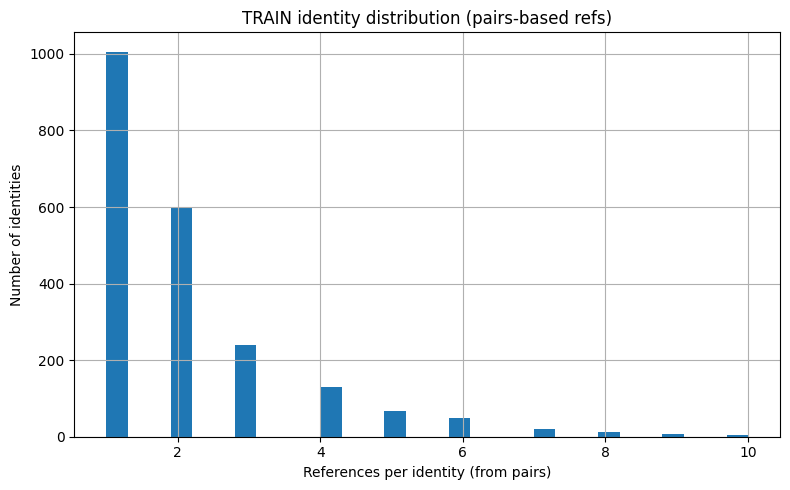

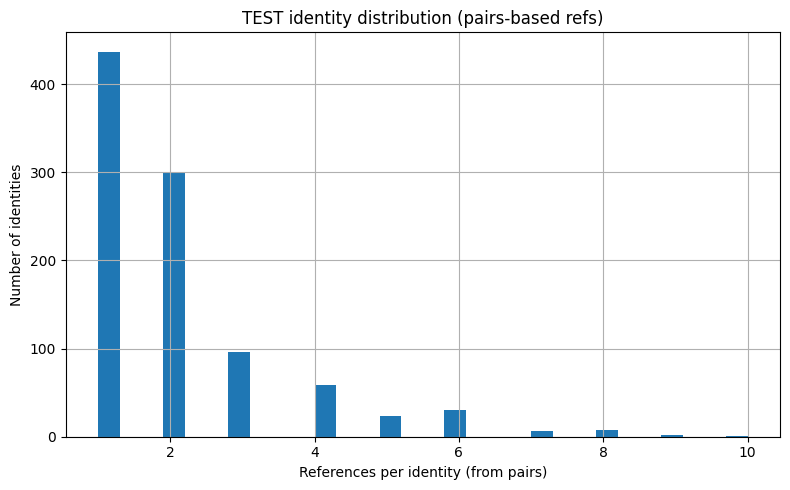

In [17]:
def plot_identity_hist(id_counts: Counter, title: str):
    vals = np.array(list(id_counts.values()))
    plt.figure(figsize=(8,5))
    plt.hist(vals, bins=30)
    plt.xlabel("References per identity (from pairs)")
    plt.ylabel("Number of identities")
    plt.title(title)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_identity_hist(train_summary["id_counts"], "TRAIN identity distribution (pairs-based refs)")
plot_identity_hist(test_summary["id_counts"],  "TEST identity distribution (pairs-based refs)")


## Full-images statistics (scan all identities under `images/`)

This section answers the same kind of questions, but for the **entire dataset on disk**:
- How many identities exist in `images/`
- How many images total exist on disk
- Distribution of number of images per identity
- Dataset disk size
- Image size distribution (width/height)


In [32]:
def scan_images_folder(images_root: Path):
    # identities are subfolders
    id_dirs = [p for p in images_root.iterdir() if p.is_dir()]
    identities = sorted([p.name for p in id_dirs])

    all_images = []
    per_identity = {}

    for d in id_dirs:
        imgs = sorted([p for p in d.glob("*.jpg")])
        # also accept png just in case
        imgs += sorted([p for p in d.glob("*.png")])
        per_identity[d.name] = imgs
        all_images.extend(imgs)

    return identities, per_identity, all_images

all_identities, images_by_id, all_image_files = scan_images_folder(IMAGES_ROOT)

print("== ALL IMAGES (folder scan) ==")
print("identities (folders):", len(all_identities))
print("total image files:", len(all_image_files))

# Disk size
total_bytes_all = sum(p.stat().st_size for p in all_image_files)
print("disk size (all images):", f"{total_bytes_all/1024/1024:.2f} MB")

# Distribution of images per identity
img_counts = np.array([len(images_by_id[i]) for i in all_identities], dtype=int)
print("min/mean/max images per identity:", int(img_counts.min()), float(img_counts.mean()), int(img_counts.max()))


== ALL IMAGES (folder scan) ==
identities (folders): 5749
total image files: 13233
disk size (all images): 96.28 MB
min/mean/max images per identity: 1 2.301791615933206 530


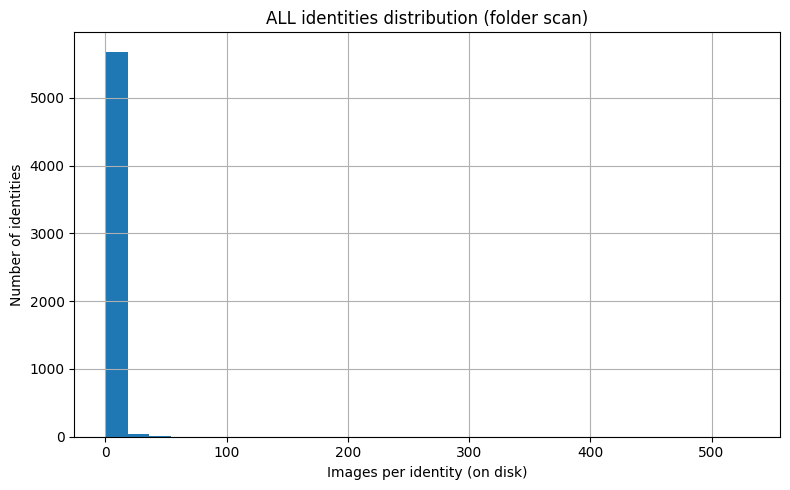

Top 10 identities by #images:
  George_W_Bush                  530
  Colin_Powell                   236
  Tony_Blair                     144
  Donald_Rumsfeld                121
  Gerhard_Schroeder              109
  Ariel_Sharon                   77
  Hugo_Chavez                    71
  Junichiro_Koizumi              60
  Jean_Chretien                  55
  John_Ashcroft                  53

Bottom 10 identities by #images:
  Zeng_Qinghong                  1
  Zhang_Yimou                    1
  Zhong_Nanshan                  1
  Ziwang_Xu                      1
  Zoe_Ball                       1
  Zorica_Radovic                 1
  Zulfiqar_Ahmed                 1
  Zumrati_Juma                   1
  Zurab_Tsereteli                1
  Zydrunas_Ilgauskas             1


In [33]:
# Plot distribution: images per identity (folder scan)
plt.figure(figsize=(8,5))
plt.hist(img_counts, bins=30)
plt.xlabel("Images per identity (on disk)")
plt.ylabel("Number of identities")
plt.title("ALL identities distribution (folder scan)")
plt.grid(True)
plt.tight_layout()
plt.show()

# Show top/bottom identities
pairs = sorted(((i, len(images_by_id[i])) for i in all_identities), key=lambda x: x[1], reverse=True)
print("Top 10 identities by #images:")
for i, c in pairs[:10]:
    print(f"  {i:30s} {c}")

print("\nBottom 10 identities by #images:")
for i, c in pairs[-10:]:
    print(f"  {i:30s} {c}")


### Train/Test coverage vs full images

Here we compare identities present in pairs files to the full set of identities on disk.


In [20]:
all_set = set(all_identities)

pairs_train_ids = train_summary["uniq_ids"]
pairs_test_ids  = test_summary["uniq_ids"]
pairs_all_ids   = pairs_train_ids | pairs_test_ids

print("Coverage vs full images:")
print("  identities on disk:", len(all_set))
print("  identities referenced by pairs (train U test):", len(pairs_all_ids))
print("  identities NOT referenced by any pairs:", len(all_set - pairs_all_ids))

print("\nBreakdown:")
print("  referenced in TRAIN pairs:", len(pairs_train_ids))
print("  referenced in TEST pairs :", len(pairs_test_ids))
print("  referenced in both       :", len(pairs_train_ids & pairs_test_ids))


Coverage vs full images:
  identities on disk: 5750
  identities referenced by pairs (train U test): 3095
  identities NOT referenced by any pairs: 2655

Breakdown:
  referenced in TRAIN pairs: 2132
  referenced in TEST pairs : 963
  referenced in both       : 0


## Image size / resolution statistics (folder scan)

We sample a subset (or all) of images to compute width/height statistics.


scanned images: 2000 bad: 0
width : min/mean/max: 250 250.0 250
height: min/mean/max: 250 250.0 250


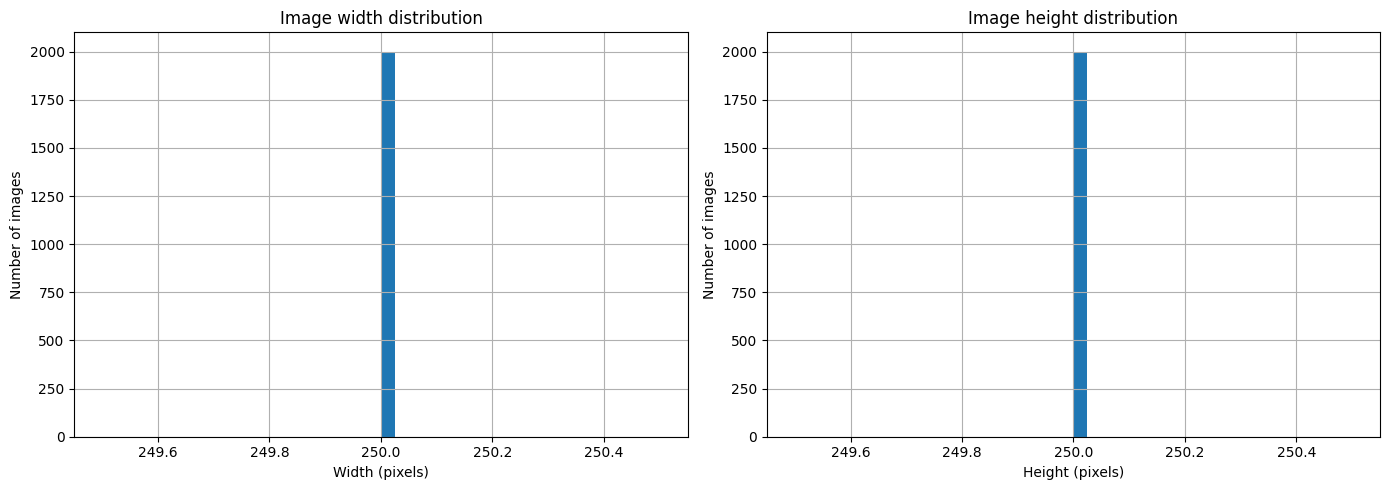

In [30]:
MAX_FOR_SIZE_SCAN = 2000

sample_for_size = all_image_files
if len(sample_for_size) > MAX_FOR_SIZE_SCAN:
    sample_for_size = random.sample(sample_for_size, MAX_FOR_SIZE_SCAN)

sizes = []
bad = 0
for p in sample_for_size:
    try:
        with Image.open(p) as im:
            w, h = im.size
        sizes.append((w, h))
    except Exception:
        bad += 1

sizes = np.array(sizes, dtype=int)

print("scanned images:", len(sizes), "bad:", bad)
print("width : min/mean/max:",
      int(sizes[:,0].min()), float(sizes[:,0].mean()), int(sizes[:,0].max()))
print("height: min/mean/max:",
      int(sizes[:,1].min()), float(sizes[:,1].mean()), int(sizes[:,1].max()))

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.hist(sizes[:,0], bins=40)
plt.xlabel("Width (pixels)")
plt.ylabel("Number of images")
plt.title("Image width distribution")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.hist(sizes[:,1], bins=40)
plt.xlabel("Height (pixels)")
plt.ylabel("Number of images")
plt.title("Image height distribution")
plt.grid(True)

plt.tight_layout()
plt.show()



## Grayscale image statistics (plots)

You requested **plots** (not just numbers) for **mean / std / variance per photo**.

We compute for each image:
- `mean_i` = mean pixel value
- `std_i` = std pixel value
- `var_i` = variance pixel value

Then we plot distributions across the dataset.

Assumption: **images are grayscale**. If an image is RGB, we convert it to grayscale via `convert("L")`.


In [25]:
import numpy as np
from PIL import Image
import random

def dataset_spatial_stats_gray(
    paths,
    max_images=2000,
    seed=42,
    resize_to=None,   # e.g. (250, 250) if sizes differ
):
    rng = random.Random(seed)

    paths = [p for p in paths if p.exists()]
    if len(paths) > max_images:
        paths = rng.sample(paths, max_images)

    imgs = []
    for p in paths:
        try:
            with Image.open(p) as im:
                im = im.convert("L")  # grayscale
                if resize_to is not None:
                    im = im.resize(resize_to, Image.BILINEAR)
                arr = np.asarray(im, dtype=np.float32) / 255.0
                imgs.append(arr)
        except Exception:
            continue

    imgs = np.stack(imgs, axis=0)  # (N, H, W)

    mean_img = imgs.mean(axis=0)
    std_img  = imgs.std(axis=0)
    var_img  = imgs.var(axis=0)

    return mean_img, std_img, var_img, imgs.shape[0]


In [26]:
import matplotlib.pyplot as plt

def plot_stat_images(mean_img, std_img, var_img):
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(mean_img, cmap="gray")
    plt.title("Mean image")
    plt.axis("off")
    plt.colorbar(fraction=0.046)

    plt.subplot(1, 3, 2)
    plt.imshow(std_img, cmap="hot")
    plt.title("Std image")
    plt.axis("off")
    plt.colorbar(fraction=0.046)

    plt.subplot(1, 3, 3)
    plt.imshow(var_img, cmap="hot")
    plt.title("Variance image")
    plt.axis("off")
    plt.colorbar(fraction=0.046)

    plt.tight_layout()
    plt.show()


Images used: 3000


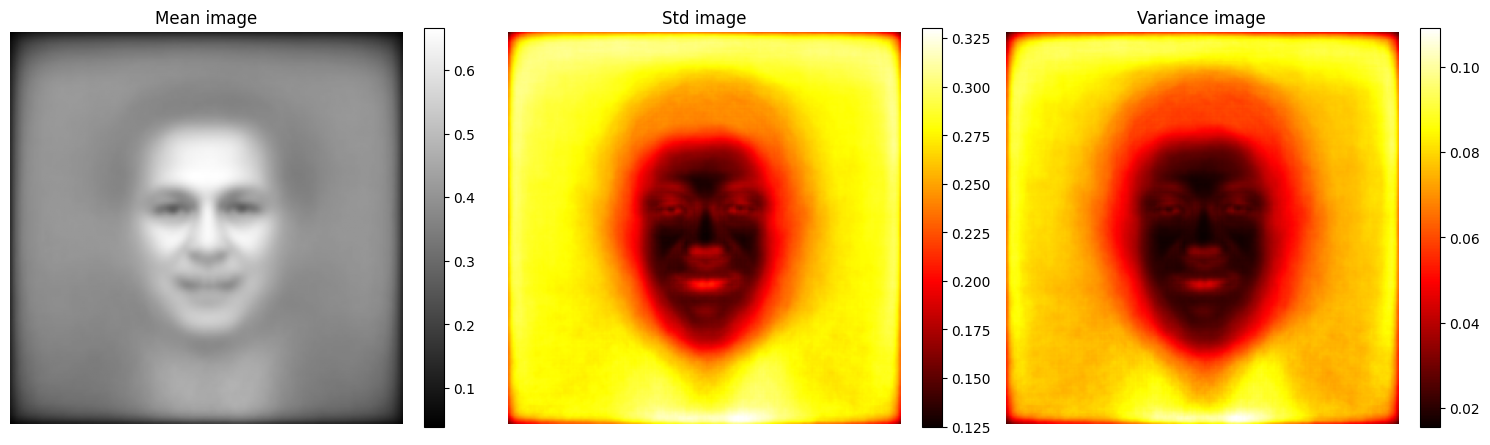

In [27]:
TARGET_SIZE = (250, 250)  # match your model input

mean_img, std_img, var_img, n_used = dataset_spatial_stats_gray(
    all_image_files,
    max_images=3000,
    resize_to=TARGET_SIZE
)

print("Images used:", n_used)
plot_stat_images(mean_img, std_img, var_img)


## Visual sanity check (grayscale)

We display random images and annotate:
- identity
- resolution
- per-image mean/std


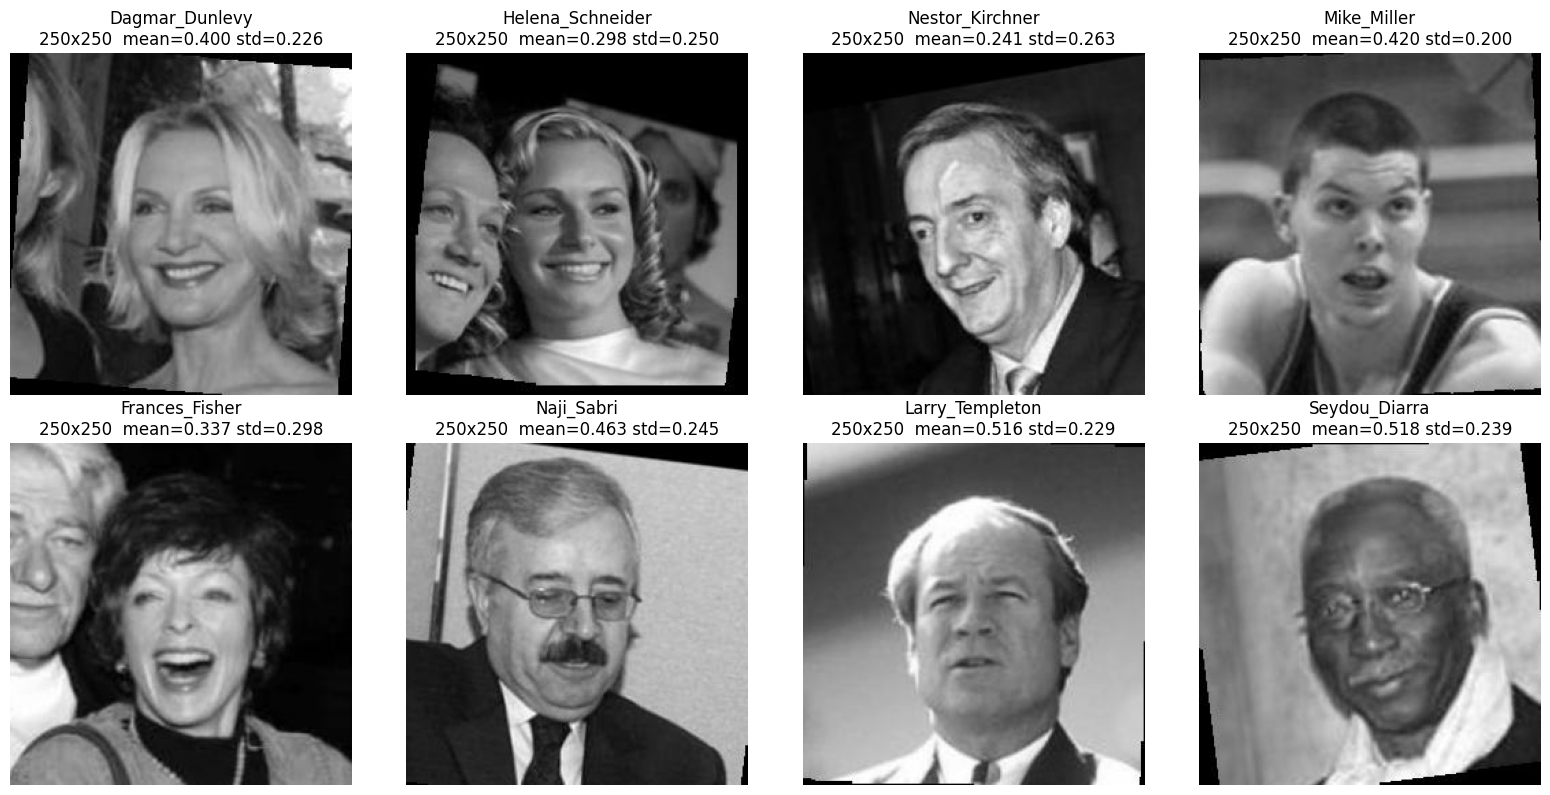

In [28]:
def show_random_samples(images_by_id, k=8, seed=0):
    rng = random.Random(seed)
    ids = list(images_by_id.keys())
    picks = []
    for _ in range(k):
        identity = rng.choice(ids)
        if not images_by_id[identity]:
            continue
        p = rng.choice(images_by_id[identity])
        picks.append((identity, p))

    cols = 4
    rows = int(np.ceil(len(picks)/cols))
    plt.figure(figsize=(4*cols, 4*rows))

    for i, (identity, p) in enumerate(picks, start=1):
        with Image.open(p) as im:
            im_l = im.convert("L")
            arr = np.asarray(im_l, dtype=np.float32)/255.0
            m, s = arr.mean(), arr.std()
            w, h = im.size

        plt.subplot(rows, cols, i)
        plt.imshow(im_l, cmap="gray")
        plt.axis("off")
        plt.title(f"{identity}\n{w}x{h}  mean={m:.3f} std={s:.3f}")

    plt.tight_layout()
    plt.show()

show_random_samples(images_by_id, k=8, seed=1)


## Additional useful checks (recommended)

- **Missing images referenced by pairs**: if >0, your dataset pathing or files are inconsistent.
- **Identities not used by pairs**: they exist on disk but are not part of train/test evaluation.
- **Resolution spread**: large variation may require `Resize`/`CenterCrop` consistency.
- **Brightness/contrast drift**: mean/std distributions differ between train and test may cause threshold instability.
